In [5]:
from pathlib import Path
import xarray as xr
import os
import dask
import cfgrib
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[3]

In [3]:
data_dir = Path(f"{repo_root}/DataGRIB")
files = sorted(list(data_dir.glob("*.grib")))

ds = xr.open_mfdataset(
    files, 
    engine='cfgrib', 
    combine='nested', 
    concat_dim='time',
    backend_kwargs={'indexpath': ''}
)

In [28]:
print(ds.step.values)

[ 86400000000000 108000000000000 129600000000000 151200000000000
 172800000000000]


In [4]:
print(ds)

<xarray.Dataset> Size: 134MB
Dimensions:            (time: 3100, step: 5, latitude: 22, longitude: 49)
Coordinates:
  * time               (time) datetime64[ns] 25kB 2017-11-01 ... 2026-03-03
  * step               (step) timedelta64[ns] 40B 1 days 00:00:00 ... 2 days ...
    valid_time         (time, step) datetime64[ns] 124kB dask.array<chunksize=(31, 5), meta=np.ndarray>
  * latitude           (latitude) float64 176B 56.42 56.3 56.17 ... 53.92 53.8
  * longitude          (longitude) float64 392B 20.9 21.02 21.15 ... 26.77 26.9
    number             int64 8B 0
    surface            float64 8B 0.0
    heightAboveGround  float64 8B 2.0
Data variables:
    tp                 (time, step, latitude, longitude) float32 67MB dask.array<chunksize=(31, 5, 22, 49), meta=np.ndarray>
    t2m                (time, step, latitude, longitude) float32 67MB dask.array<chunksize=(31, 5, 22, 49), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_ce

In [29]:
t2m_targets = [pd.Timedelta(hours=h) for h in [24, 30, 36, 42]] 
tp_start = pd.Timedelta(hours=24)
tp_end = pd.Timedelta(hours=48)

In [30]:
t2m_avg = ds['t2m'].sel(step=t2m_targets).mean(dim='step')

In [35]:
tp_diff = ds['tp'].sel(step=tp_end) - ds['tp'].sel(step=tp_start)

In [37]:
ds_final = xr.Dataset({'t2m': t2m_avg, 'tp': tp_diff})
print(ds_final)

<xarray.Dataset> Size: 27MB
Dimensions:            (time: 3100, latitude: 22, longitude: 49)
Coordinates:
  * time               (time) datetime64[ns] 25kB 2017-11-01 ... 2026-03-03
  * latitude           (latitude) float64 176B 56.42 56.3 56.17 ... 53.92 53.8
  * longitude          (longitude) float64 392B 20.9 21.02 21.15 ... 26.77 26.9
    number             int64 8B 0
    surface            float64 8B 0.0
    heightAboveGround  float64 8B 2.0
Data variables:
    t2m                (time, latitude, longitude) float32 13MB dask.array<chunksize=(31, 22, 49), meta=np.ndarray>
    tp                 (time, latitude, longitude) float32 13MB dask.array<chunksize=(31, 22, 49), meta=np.ndarray>


In [38]:
ds_final.to_netcdf(f"{repo_root}/DataGRIB/lithuania_ecmwf_2017_2026.nc")

In [39]:
ds = xr.open_dataset(f"{repo_root}/DataGRIB/lithuania_ecmwf_2017_2026.nc")

In [40]:
lats = [54.68] # Vilnius
lons = [25.27]

subset_points_tp = ds.sel(
    latitude=lats, 
    longitude=lons, 
    method='nearest'
)

In [41]:
df = subset_points_tp.to_dataframe().reset_index()

In [42]:
df.head()

,time,latitude,longitude,t2m,tp,number,surface,heightAboveGround
0,2017-11-01,54.675,25.275,281.280243,1.176508e+01,0,0.0,2.0
1,2017-11-02,54.675,25.275,280.484131,5.309649e-01,0,0.0,2.0
2,2017-11-03,54.675,25.275,280.077271,4.097846e-01,0,0.0,2.0
3,2017-11-04,54.675,25.275,279.417023,2.980232e-08,0,0.0,2.0
4,2017-11-05,54.675,25.275,279.310059,1.840352e-02,0,0.0,2.0


In [43]:
df['t2m'] = df['t2m'] - 272.15
df = df[['time', 'tp', 't2m']]

In [45]:
df.head()

,time,tp,t2m
0,2017-11-01,1.176508e+01,9.130249
1,2017-11-02,5.309649e-01,8.334137
2,2017-11-03,4.097846e-01,7.927277
3,2017-11-04,2.980232e-08,7.267029
4,2017-11-05,1.840352e-02,7.160065


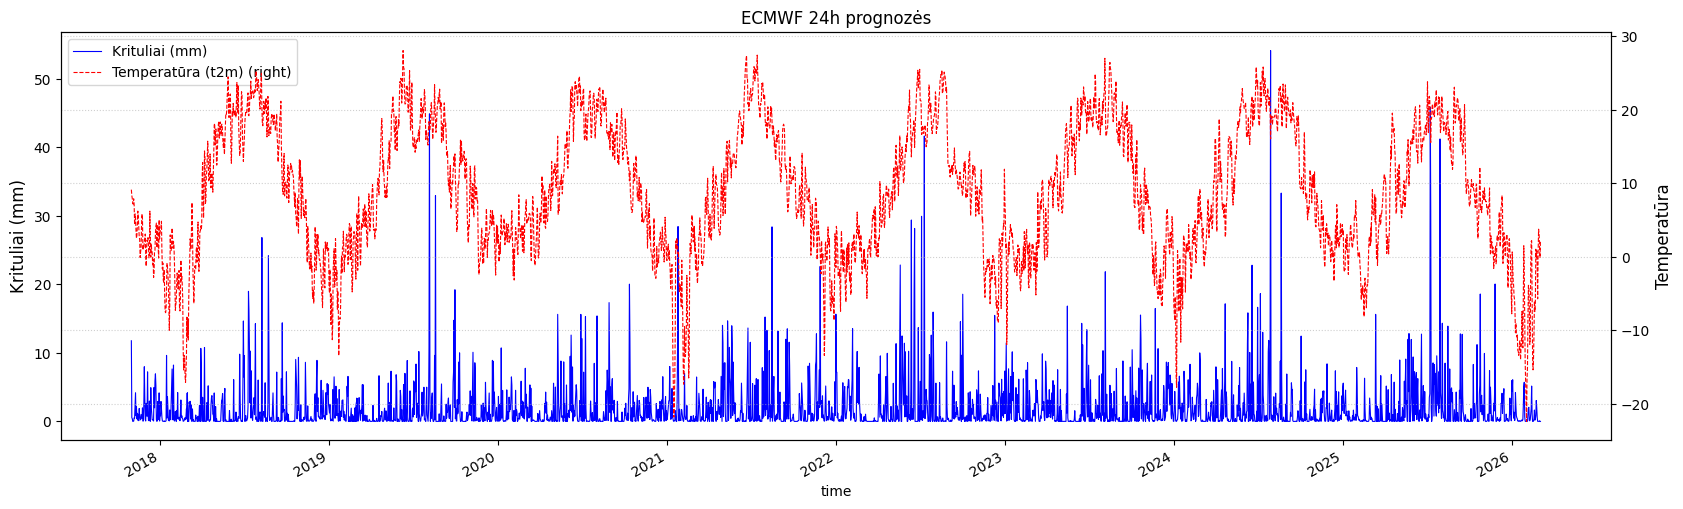

In [46]:
import matplotlib.pyplot as plt

df_time_idx = df.set_index('time')

ax = df_time_idx.tp.plot(figsize=(20, 6), linewidth=0.8, color='blue', label='Krituliai (mm)')
df_time_idx.t2m.plot(ax=ax, secondary_y=True, linewidth=0.8, linestyle='--', color='red', label='Temperatūra (t2m)')

ax.set_ylabel('Krituliai (mm)', fontsize=12)
ax.right_ax.set_ylabel('Temperatūra', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax.right_ax.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title("ECMWF 24h prognozės")

plt.show()

In [47]:
df.to_csv(f"Vilnius_ecmwf_data_2017_2026.csv", index=False)